##  Section 1 – Imports & Setup
Load all required libraries and configure plotting style and random seed.

In [1]:
# ── IMPORTS & SETUP ─────────────────────────────────────────────────────────
# Loads libraries for: data handling (pandas, numpy), plotting (matplotlib,
# seaborn), regression models and tuning tools (scikit-learn),
# and regression metrics (MAE, MSE, RMSE, R2)
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print('Libraries loaded')

Libraries loaded


##  Section 2 – Load Dataset
Set the working directory so Python knows where to find the CSV file, then load it.

The dataset contains 545 residential property records with 12 features covering physical characteristics, amenities, and location preferences. Unlike the previous two datasets, which involved classification tasks, this is a pure regression problem: predicting the continuous sale price of a house based on its attributes. Regression metrics, including MAE, RMSE, and R2, are used throughout this report to evaluate model performance.

In [2]:
# ── SET WORKING DIRECTORY ───────────────────────────────────────────────────
# Change Python's current folder to your ML_Project directory
# This ensures pd.read_csv() can find Housing.csv by name alone
# os.listdir() confirms the file is visible in the folder
# Set working directory — update this path to your ML_Project folder
os.chdir(r'C:\Users\Julia\Desktop\CSCI 164-Final Project\data')
print(os.getcwd())
print(os.listdir('.'))

C:\Users\Julia\Desktop\CSCI 164-Final Project\data
['heart.csv', 'Housing.csv', 'spotify_yearly']


In [4]:
# ── LOAD DATASET ────────────────────────────────────────────────────────────
# Read Housing.csv into a pandas DataFrame
# df.head() previews the first 5 rows to confirm it loaded correctly
# Expected: 545 rows x 13 columns
# Load dataset
# Download from: https://www.kaggle.com/datasets/yasserh/housing-prices-dataset
# Save the CSV as 'Housing.csv' inside your ML_Project folder
df = pd.read_csv('Housing.csv')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()

Shape: 545 rows x 13 columns


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


##  Section 3 – Exploratory Data Analysis (EDA)
Inspect the dataset structure, statistics, missing values, and target distribution before preprocessing.

Why This Dataset?

•	Regression task: Complements the classification tasks in the other two datasets, allowing demonstration of regression-specific metrics (MAE, RMSE, R2) and visualizations (residual plots, actual vs. predicted).

•	Real-world applicability: Housing price prediction is one of the most widely studied ML applications, with direct relevance to real estate markets, mortgage lending, and property valuation.

•	Mixed feature types: The combination of continuous numeric features and binary categorical features tests the full preprocessing pipeline including ordinal encoding and binary mapping.


In [5]:
# ── DATA TYPES & STRUCTURE ──────────────────────────────────────────────────
# df.info() shows: column names, data types (int64/object),
# and confirms whether all 545 rows are non-null
# Categorical columns (yes/no text) will need encoding before modeling
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [7]:
# ── SUMMARY STATISTICS ──────────────────────────────────────────────────────
# df.describe() shows min, max, mean, std, and quartiles
# for numeric columns only (area, bedrooms, bathrooms, stories, parking, price)
# Helps spot outliers — e.g. very large area or unusually high price
df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,545.0,4.766729e+06,1.870440e+06,1750000.0,3430000.0,4340000.0,5740000.0,13300000.0
area,545.0,5.150541e+03,2.170141e+03,1650.0,3600.0,4600.0,6360.0,16200.0
bedrooms,545.0,2.965138e+00,7.380639e-01,1.0,2.0,3.0,3.0,6.0
bathrooms,545.0,1.286239e+00,5.024696e-01,1.0,1.0,1.0,2.0,4.0
stories,545.0,1.805505e+00,8.674925e-01,1.0,1.0,2.0,2.0,4.0
parking,545.0,6.935780e-01,8.615858e-01,0.0,0.0,0.0,1.0,3.0


In [8]:
# ── MISSING VALUE CHECK ─────────────────────────────────────────────────────
# Count nulls per column — any nulls would need imputation before modeling
# This dataset has 0 missing values across all 545 rows so no action needed
# Missing values check
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found')

Missing values per column:
No missing values found


##  Section 4 – Visualizations
Plot the target distribution, feature distributions, scatter plots, and feature-vs-price relationships.

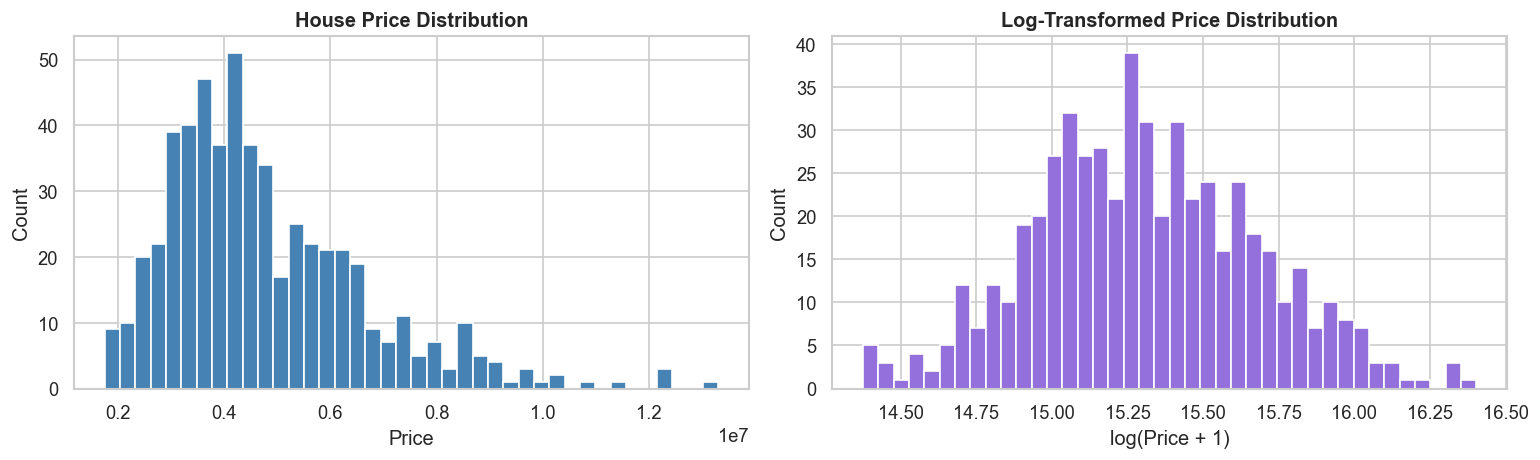

In [9]:
# ── TARGET VARIABLE: PRICE DISTRIBUTION ─────────────────────────────────────
# Left plot: raw price histogram — right-skewed means most houses are cheaper
#            with a long tail of expensive properties
# Right plot: log-transformed price — more symmetric, shows what a
#             log(price) target would look like for improved model fit
# We use raw price as the target but log-transform is shown for reference
# Target variable — price distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['price'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('House Price Distribution', fontweight='bold')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(df['price']), bins=40, color='mediumpurple', edgecolor='white')
axes[1].set_title('Log-Transformed Price Distribution', fontweight='bold')
axes[1].set_xlabel('log(Price + 1)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

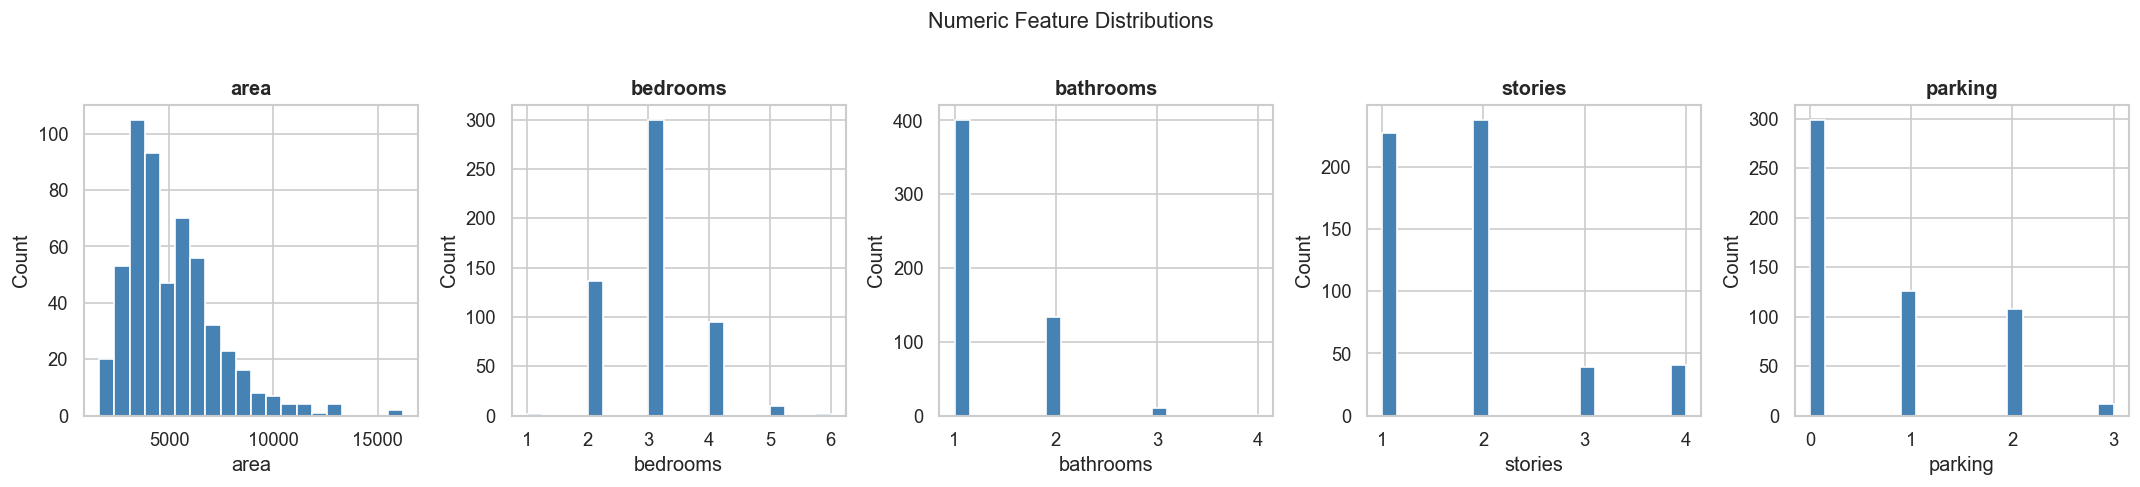

In [10]:
# ── NUMERIC FEATURE DISTRIBUTIONS ───────────────────────────────────────────
# Histograms for: area, bedrooms, bathrooms, stories, parking
# Helps identify: skewness, rare values, or discrete vs continuous nature
# Most features are discrete counts (1-5 range) except area (continuous)
# Numeric feature distributions
num_cols = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col in zip(axes, num_cols):
    ax.hist(df[col], bins=20, color='steelblue', edgecolor='white')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.suptitle('Numeric Feature Distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

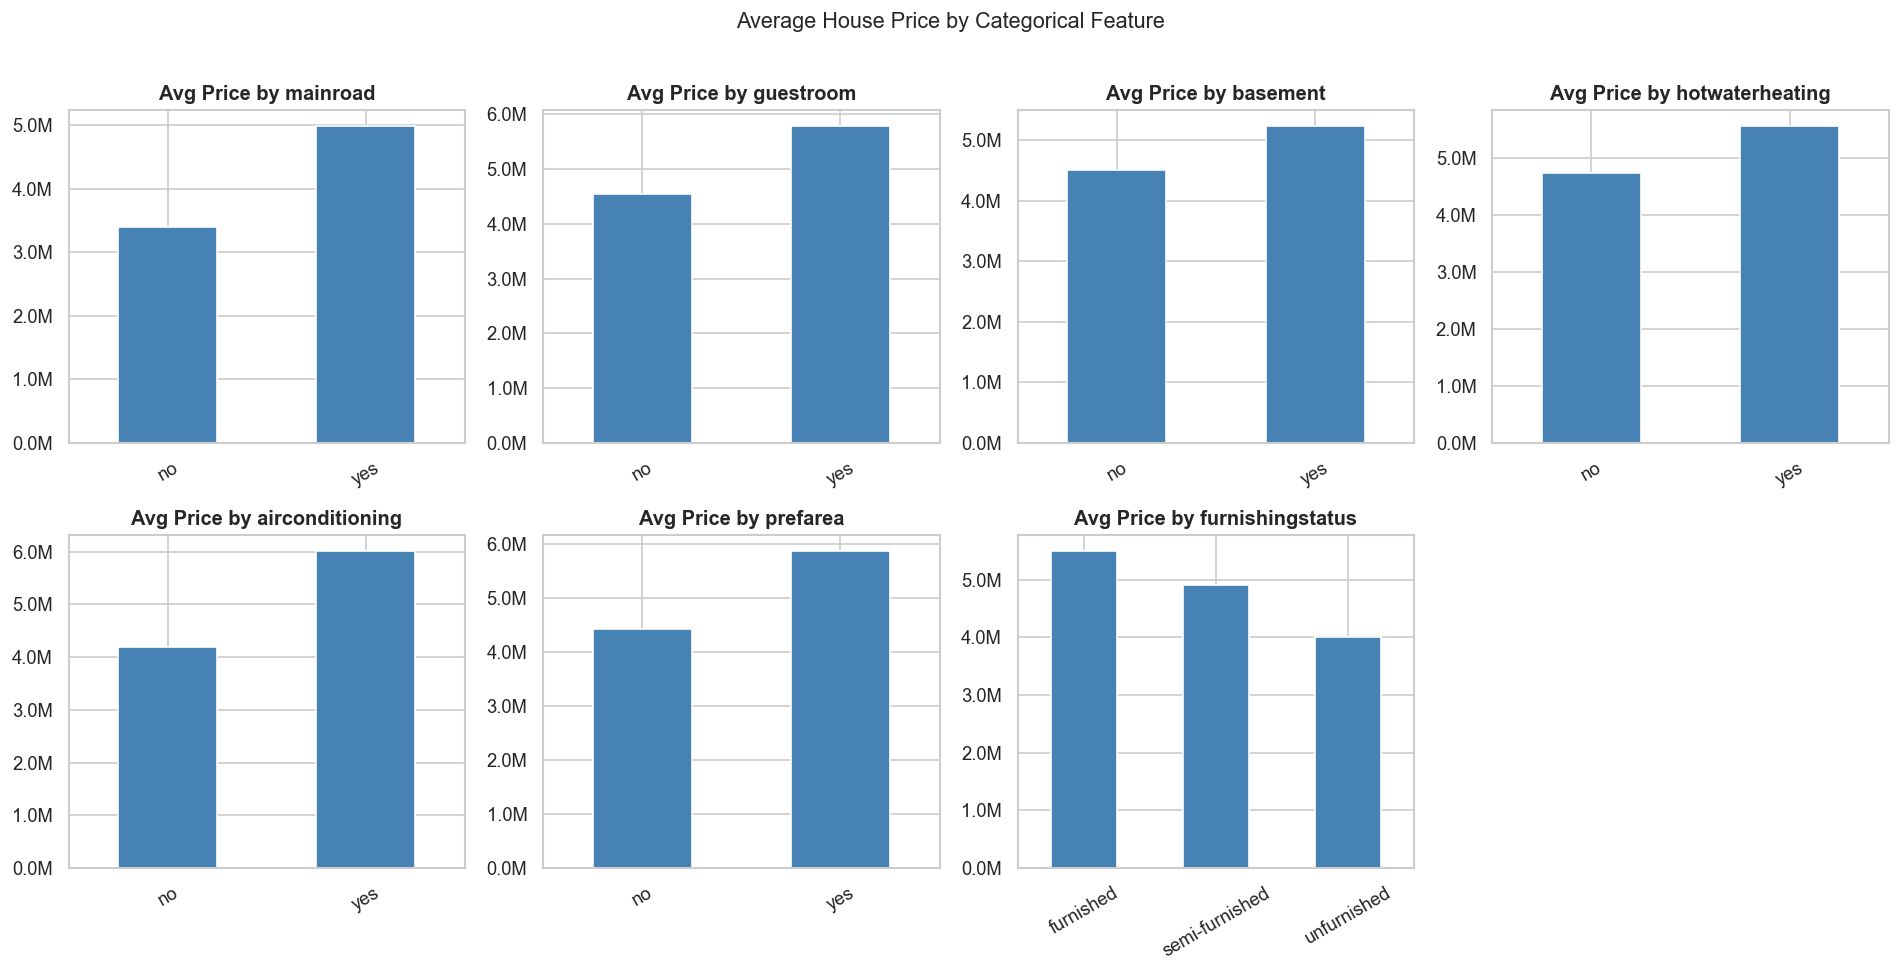

In [11]:
# ── AVERAGE PRICE BY CATEGORICAL FEATURE ────────────────────────────────────
# Bar charts showing mean house price grouped by each yes/no feature
# and furnishing status — taller bar = higher average price for that group
# Helps identify which amenities have the strongest price impact
# Categorical feature value counts vs price
cat_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
            'airconditioning', 'prefarea', 'furnishingstatus']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for ax, col in zip(axes, cat_cols):
    df.groupby(col)['price'].mean().plot(kind='bar', ax=ax,
                                         color='steelblue', edgecolor='white')
    ax.set_title(f'Avg Price by {col}', fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

axes[-1].set_visible(False)
plt.suptitle('Average House Price by Categorical Feature', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

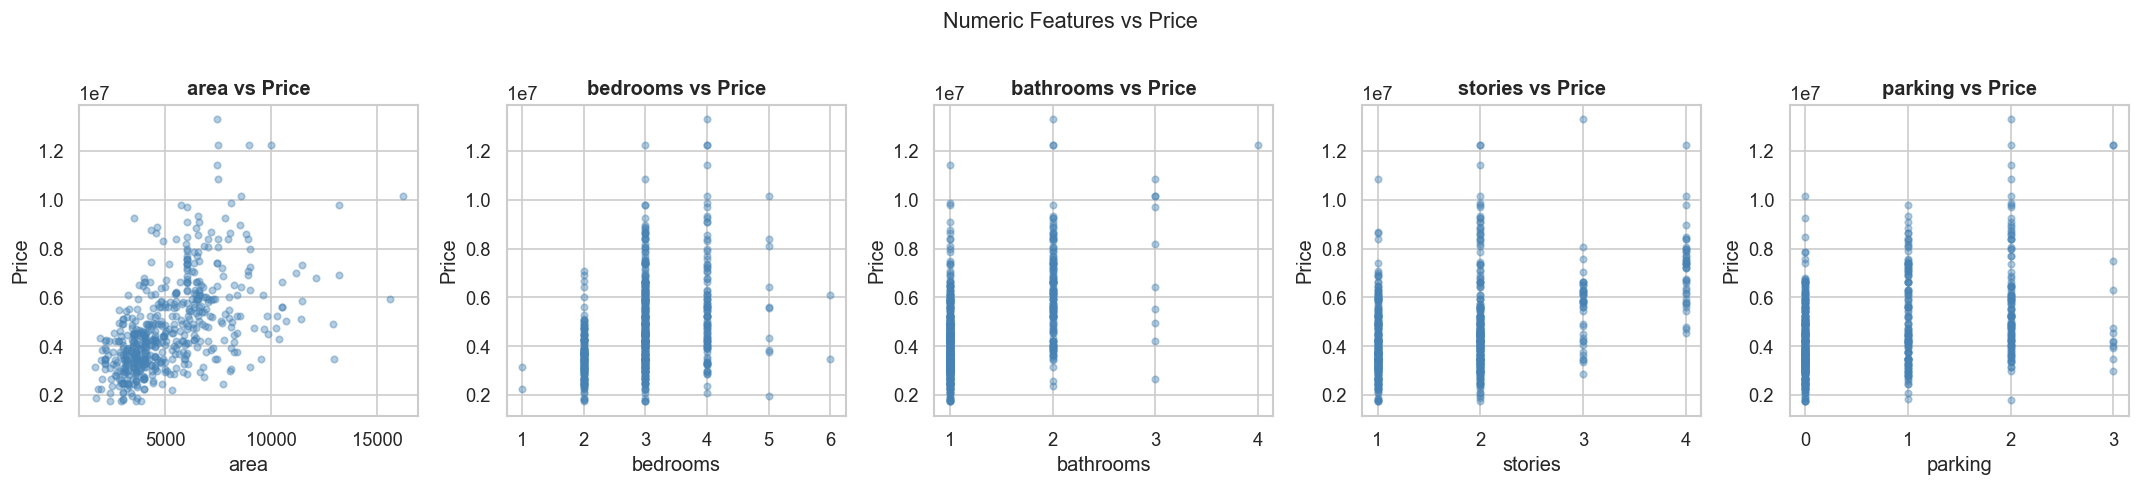

In [12]:
# ── SCATTER PLOTS: NUMERIC FEATURES VS PRICE ────────────────────────────────
# Each dot = one house; x-axis = feature value, y-axis = sale price
# Upward trend = positive correlation with price
# Area is expected to show the strongest positive relationship
# Scatter plots: numeric features vs price
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col in zip(axes, num_cols):
    ax.scatter(df[col], df['price'], alpha=0.4, color='steelblue', s=15)
    ax.set_title(f'{col} vs Price', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Price')

plt.suptitle('Numeric Features vs Price', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

##  Section 5 – Preprocessing
Clean and encode the data so all features are numeric and ready for modeling.

In [13]:
# ── PREPROCESSING: ENCODE CATEGORICAL FEATURES ──────────────────────────────
# Step 1: Copy raw DataFrame to avoid modifying the original
# Step 2: Remove duplicate rows (none found in this dataset)
# Step 3: Encode 6 binary yes/no columns → 1/0 integers
#         (mainroad, guestroom, basement, hotwaterheating,
#          airconditioning, prefarea)
# Step 4: Encode furnishingstatus as ordinal:
#         furnished=2, semi-furnished=1, unfurnished=0
#         (ordinal because furnishing level has a natural order)
# Preprocessing
df_clean = df.copy()

# Remove duplicates
before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
df_clean.reset_index(drop=True, inplace=True)
print(f'Removed {before - len(df_clean)} duplicates. Rows remaining: {len(df_clean):,}')

# Encode binary yes/no columns
binary_cols = ['mainroad', 'guestroom', 'basement',
               'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df_clean[col] = df_clean[col].map({'yes': 1, 'no': 0})

# Encode furnishingstatus (ordinal: furnished > semi-furnished > unfurnished)
furnish_map = {'furnished': 2, 'semi-furnished': 1, 'unfurnished': 0}
df_clean['furnishingstatus'] = df_clean['furnishingstatus'].map(furnish_map)

print('\nEncoding complete. Sample:')
df_clean.head(3)

Removed 0 duplicates. Rows remaining: 545

Encoding complete. Sample:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,2
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,2
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1


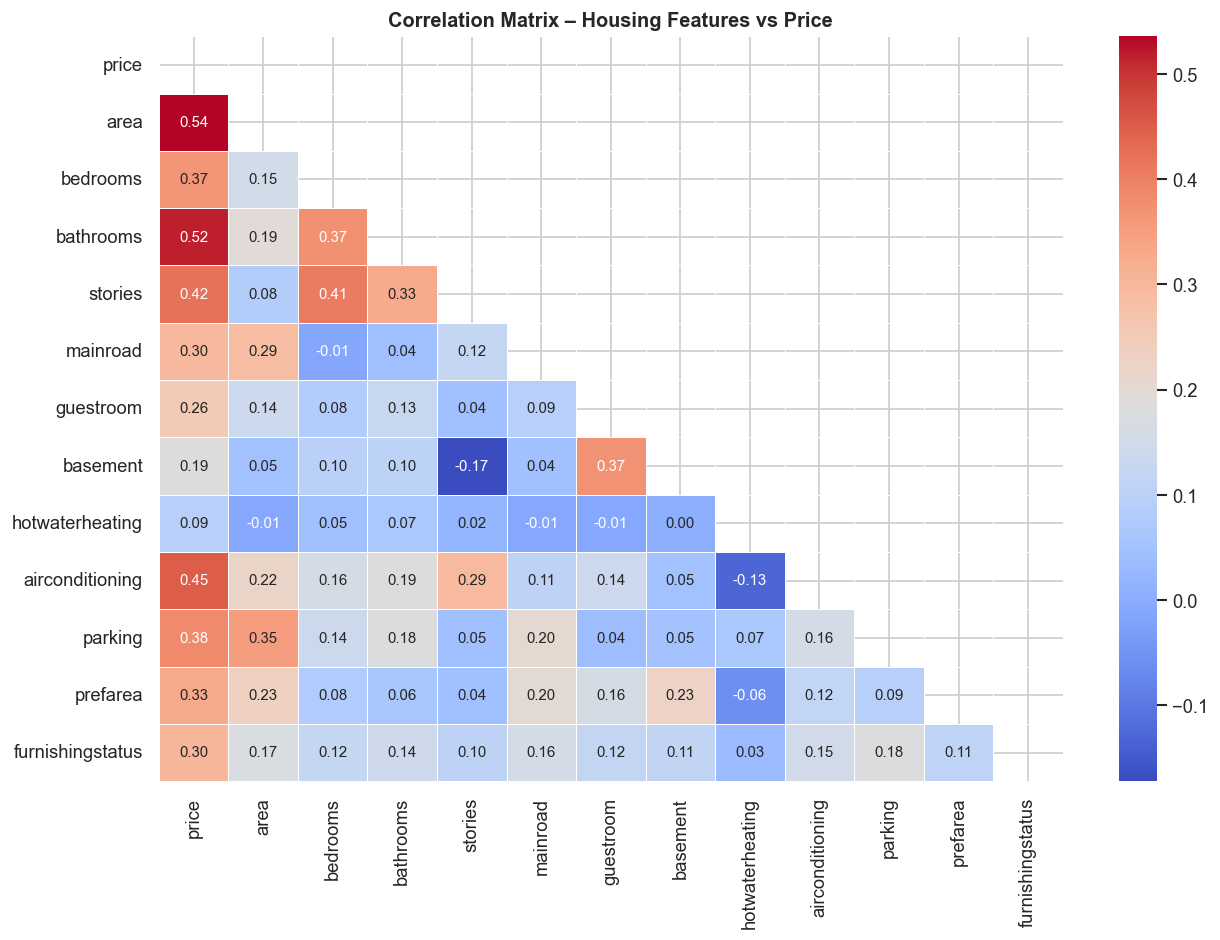

In [14]:
# ── CORRELATION HEATMAP (AFTER ENCODING) ────────────────────────────────────
# Now that all features are numeric we can compute correlations
# Shows which features are most correlated with price (target)
# Also reveals multicollinearity between features (e.g. bathrooms vs stories)
# Correlation heatmap (after encoding)
corr = df_clean.corr()

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 9})
plt.title('Correlation Matrix – Housing Features vs Price', fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
# ── DEFINE FEATURES, SPLIT DATA & SCALE ─────────────────────────────────────
# FEATURES: all 12 columns except price used as model inputs
# TARGET (y): the continuous price column in Indian Rupees
# SPLIT: 80% training (436 rows) / 20% test (109 rows) — random, not stratified
#        (stratification is for classification; regression uses random split)
# SCALING: StandardScaler centers data (mean=0, std=1) for Linear Regression,
#          Ridge, and k-NN — Decision Tree uses unscaled features
# Define features and target
FEATURES = ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
            'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
            'parking', 'prefarea', 'furnishingstatus']

X = df_clean[FEATURES]
y = df_clean['price']

print(f'Target (price) — Mean: ${y.mean():,.0f} | Median: ${y.median():,.0f}')
print(f'Min: ${y.min():,.0f} | Max: ${y.max():,.0f}')

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE)

print(f'\nTrain: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')

# Feature scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print('Scaling complete')

Target (price) — Mean: $4,766,729 | Median: $4,340,000
Min: $1,750,000 | Max: $13,300,000

Train: 436 | Test: 109
Scaling complete


##  Section 6 – Baseline Model Development
Define the regression evaluation helper and train four baseline models.

In [16]:
# ── REGRESSION EVALUATION HELPER FUNCTION ───────────────────────────────────
# evaluate_regressor() does the following for any regressor passed to it:
#   1. Fits (trains) the model on training data
#   2. Predicts house prices on the test set
#   3. Calculates regression metrics:
#      MAE  = Mean Absolute Error (avg dollar error)
#      MSE  = Mean Squared Error (penalizes large errors more)
#      RMSE = Root MSE (same units as price, easier to interpret)
#      R2   = how much price variance the model explains (0-1 scale)
#   4. Runs 5-fold cross-validation scored by R2
# Regression evaluation helper
def evaluate_regressor(model, X_tr, X_te, y_tr, y_te, name, cv=5):
    model.fit(X_tr, y_tr)
    y_pred    = model.predict(X_te)
    mae       = mean_absolute_error(y_te, y_pred)
    mse       = mean_squared_error(y_te, y_pred)
    rmse      = np.sqrt(mse)
    r2        = r2_score(y_te, y_pred)
    cv_scores = cross_val_score(
        model, X_tr, y_tr,
        cv=KFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE),
        scoring='r2')
    print(f'\n{"="*55}')
    print(f'  {name}')
    print(f'{"="*55}')
    print(f'  MAE  : ${mae:,.0f}')
    print(f'  RMSE : ${rmse:,.0f}')
    print(f'  R2   : {r2:.4f}')
    print(f'  CV R2: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')
    return {'model': model, 'name': name, 'y_pred': y_pred,
            'mae': mae, 'mse': mse, 'rmse': rmse, 'r2': r2,
            'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std()}

In [17]:
# ── BASELINE MODEL 1: LINEAR REGRESSION ─────────────────────────────────────
# Fits a straight-line relationship between features and price
# Uses scaled features — required for coefficient interpretability
# Serves as the primary baseline and is directly comparable to prior work
# Model 1 — Linear Regression
res_lr = evaluate_regressor(
    LinearRegression(),
    X_train_sc, X_test_sc, y_train, y_test,
    'Linear Regression'
)


  Linear Regression
  MAE  : $979,680
  RMSE : $1,331,071
  R2   : 0.6495
  CV R2: 0.6486 +/- 0.0469


In [18]:
# ── BASELINE MODEL 2: RIDGE REGRESSION ──────────────────────────────────────
# Like Linear Regression but adds an L2 penalty to shrink large coefficients
# alpha=1.0 is the default regularization strength (will be tuned later)
# Helps prevent overfitting when features are correlated
# Model 2 — Ridge Regression
res_ridge = evaluate_regressor(
    Ridge(alpha=1.0),
    X_train_sc, X_test_sc, y_train, y_test,
    'Ridge Regression'
)


  Ridge Regression
  MAE  : $979,549
  RMSE : $1,331,290
  R2   : 0.6494
  CV R2: 0.6487 +/- 0.0466


In [19]:
# ── BASELINE MODEL 3: DECISION TREE REGRESSOR ───────────────────────────────
# Splits data into branches based on feature thresholds to predict price
# Uses UNSCALED features — tree-based models do not need scaling
# Untuned tree (no depth limit) will likely overfit on 436 training rows
# Model 3 — Decision Tree Regressor
res_dt = evaluate_regressor(
    DecisionTreeRegressor(random_state=RANDOM_STATE),
    X_train, X_test, y_train, y_test,
    'Decision Tree Regressor (untuned)'
)


  Decision Tree Regressor (untuned)
  MAE  : $1,270,789
  RMSE : $1,718,102
  R2   : 0.4160
  CV R2: 0.1933 +/- 0.3251


In [20]:
# ── BASELINE MODEL 4: K-NN REGRESSOR (k=7) ─────────────────────────────────
# Predicts price as the average price of the 7 most similar houses
# Uses scaled features — distance-based models require scaling
# k=7 is a reasonable starting point; will be tuned with GridSearchCV
# Model 4 — k-NN Regressor
res_knn = evaluate_regressor(
    KNeighborsRegressor(n_neighbors=7),
    X_train_sc, X_test_sc, y_train, y_test,
    'k-NN Regressor (k=7)'
)


  k-NN Regressor (k=7)
  MAE  : $1,041,482
  RMSE : $1,465,304
  R2   : 0.5752
  CV R2: 0.6319 +/- 0.0175


##  Section 7 – Hyperparameter Tuning
Use GridSearchCV with 5-fold cross-validation to find the best settings for each model.

Key tuning findings: Ridge Regression benefited from stronger regularization (alpha=50) than the default (alpha=1), though the improvement in test R2 was marginal (-0.0079 vs untuned). The Decision Tree showed significant instability; its untuned CV R2 was only 0.1933 with a very high standard deviation of 0.3251, indicating severe overfitting. Pruning to max_depth=5 improved CV R2 to 0.4533, but still underperformed linear models. The k-NN performed best with k=9 and Euclidean distance using uniform weights, achieving a stable CV R2 of 0.6366

In [21]:
# ── GRIDSEARCHCV: RIDGE REGRESSION ──────────────────────────────────────────
# Tests 7 values of alpha (regularization strength):
#   Low alpha (0.01) = almost no regularization, behaves like Linear Regression
#   High alpha (500) = heavy shrinkage, underfits but very stable
# 5-fold CV scores each alpha by R2 — picks the best generalizing value
# GridSearchCV — Ridge Regression
gs_ridge = GridSearchCV(
    Ridge(),
    {'alpha': [0.01, 0.1, 1.0, 10.0, 50.0, 100.0, 500.0]},
    cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='r2', n_jobs=-1, verbose=1
)
gs_ridge.fit(X_train_sc, y_train)
print('Best params:', gs_ridge.best_params_)
print(f'Best CV R2: {gs_ridge.best_score_:.4f}')

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Best params: {'alpha': 50.0}
Best CV R2: 0.6503


In [22]:
# ── GRIDSEARCHCV: DECISION TREE REGRESSOR ───────────────────────────────────
# Tests combinations of:
#   max_depth: limits tree depth to prevent memorizing training data
#   min_samples_split: min rows needed before splitting a node
#   criterion: squared_error (penalizes large errors) vs
#              absolute_error (robust to outliers)
# 40 total combinations tested, each with 5-fold CV = 200 fits
# GridSearchCV — Decision Tree Regressor
gs_dt = GridSearchCV(
    DecisionTreeRegressor(random_state=RANDOM_STATE),
    {'max_depth': [3, 5, 7, 10, None],
     'min_samples_split': [2, 5, 10, 20],
     'criterion': ['squared_error', 'absolute_error']},
    cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='r2', n_jobs=-1, verbose=1
)
gs_dt.fit(X_train, y_train)
print('Best params:', gs_dt.best_params_)
print(f'Best CV R2: {gs_dt.best_score_:.4f}')

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best params: {'criterion': 'squared_error', 'max_depth': 5, 'min_samples_split': 10}
Best CV R2: 0.4533


In [23]:
# ── GRIDSEARCHCV: K-NN REGRESSOR ────────────────────────────────────────────
# Tests combinations of:
#   n_neighbors: k=3 to k=15 (smaller k = more local, larger k = smoother)
#   weights: uniform (all neighbors equal) vs distance (closer = more weight)
#   metric: euclidean (straight-line) vs manhattan (grid-based) distance
# 24 combinations tested, each with 5-fold CV = 120 fits
# GridSearchCV — k-NN Regressor
gs_knn = GridSearchCV(
    KNeighborsRegressor(),
    {'n_neighbors': [3, 5, 7, 9, 11, 15],
     'weights': ['uniform', 'distance'],
     'metric': ['euclidean', 'manhattan']},
    cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='r2', n_jobs=-1, verbose=1
)
gs_knn.fit(X_train_sc, y_train)
print('Best params:', gs_knn.best_params_)
print(f'Best CV R2: {gs_knn.best_score_:.4f}')

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best params: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}
Best CV R2: 0.6366


##  Section 8 – Evaluate Tuned Models
Test each best_estimator_ from GridSearchCV on the held-out test set.

In [24]:
# ── EVALUATE ALL TUNED MODELS ON TEST SET ───────────────────────────────────
# best_estimator_ = the model config with the highest CV R2 from GridSearchCV
# Each tuned model is evaluated on the 109 test rows it has never seen
# Linear Regression has no tunable hyperparameters — uses baseline result
# Evaluate all tuned models
res_ridge_tuned = evaluate_regressor(gs_ridge.best_estimator_, X_train_sc, X_test_sc, y_train, y_test, 'Ridge Regression (tuned)')
res_dt_tuned    = evaluate_regressor(gs_dt.best_estimator_,    X_train,    X_test,    y_train, y_test, 'Decision Tree (tuned)')
res_knn_tuned   = evaluate_regressor(gs_knn.best_estimator_,   X_train_sc, X_test_sc, y_train, y_test, 'k-NN Regressor (tuned)')


  Ridge Regression (tuned)
  MAE  : $978,706
  RMSE : $1,346,128
  R2   : 0.6415
  CV R2: 0.6503 +/- 0.0338

  Decision Tree (tuned)
  MAE  : $1,258,021
  RMSE : $1,689,677
  R2   : 0.4352
  CV R2: 0.4533 +/- 0.1995

  k-NN Regressor (tuned)
  MAE  : $1,034,828
  RMSE : $1,450,198
  R2   : 0.5839
  CV R2: 0.6366 +/- 0.0333


##  Section 9 – Results, Evaluation & Visualizations
Compare all models and generate all evaluation plots.

In [25]:
# ── SUMMARY COMPARISON TABLE ────────────────────────────────────────────────
# Collect MAE, RMSE, R2, CV R2, and CV Std for all 7 models into one DataFrame
# Sorted by R2 (highest first) — R2 is the primary regression metric
# MAE and RMSE are in Indian Rupees (same units as the price target)
# Summary comparison table
all_results = [res_lr, res_ridge, res_dt, res_knn,
               res_ridge_tuned, res_dt_tuned, res_knn_tuned]

summary_df = pd.DataFrame([{
    'Model'  : r['name'],
    'MAE ($)': f"{r['mae']:,.0f}",
    'RMSE ($)': f"{r['rmse']:,.0f}",
    'R2'     : round(r['r2'], 4),
    'CV R2'  : round(r['cv_mean'], 4),
    'CV Std' : round(r['cv_std'], 4)
} for r in all_results])

summary_df.sort_values('R2', ascending=False, inplace=True)
summary_df.reset_index(drop=True, inplace=True)
summary_df

,Model,MAE ($),RMSE ($),R2,CV R2,CV Std
0,Linear Regression,"979,680","1,331,071",0.6495,0.6486,0.0469
1,Ridge Regression,"979,549","1,331,290",0.6494,0.6487,0.0466
2,Ridge Regression (tuned),"978,706","1,346,128",0.6415,0.6503,0.0338
3,k-NN Regressor (tuned),"1,034,828","1,450,198",0.5839,0.6366,0.0333
4,k-NN Regressor (k=7),"1,041,482","1,465,304",0.5752,0.6319,0.0175
5,Decision Tree (tuned),"1,258,021","1,689,677",0.4352,0.4533,0.1995
6,Decision Tree Regressor (untuned),"1,270,789","1,718,102",0.4160,0.1933,0.3251


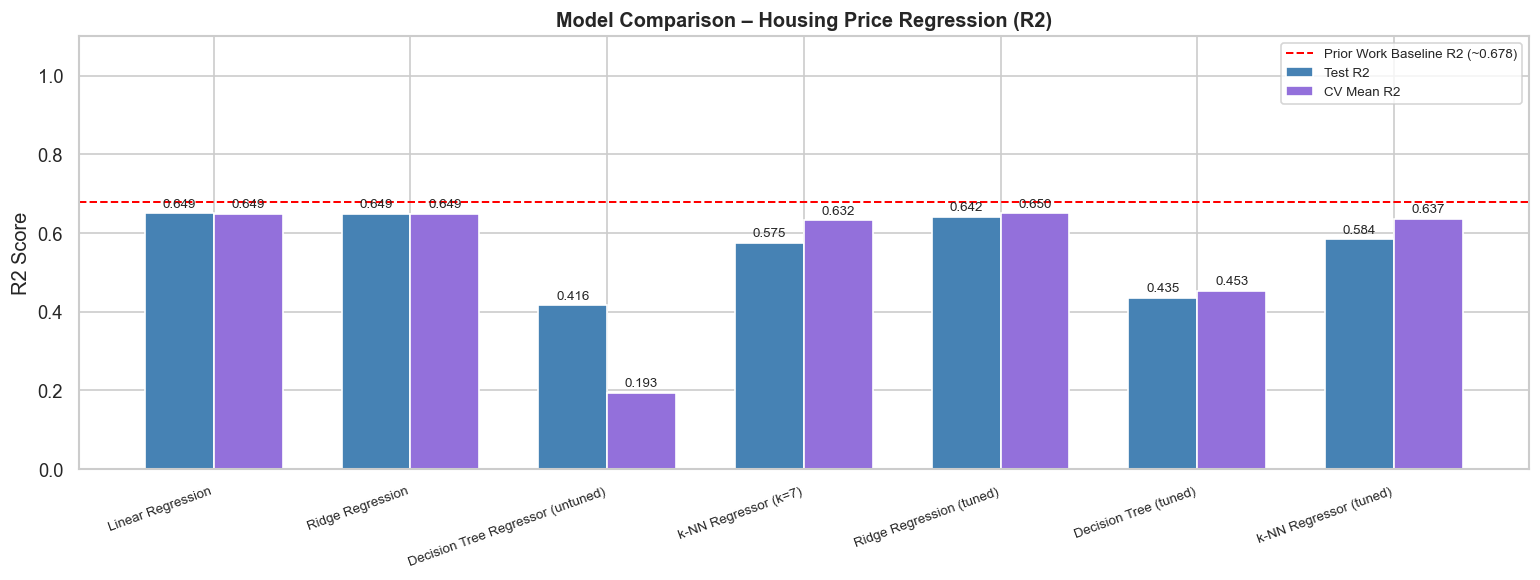

In [26]:
# ── R2 COMPARISON BAR CHART ─────────────────────────────────────────────────
# Side-by-side bars: Test R2 vs CV Mean R2 for every model
# A large gap between Test R2 and CV R2 suggests overfitting
# Red dashed line = prior work baseline R2 (~0.678 from Madhuri et al. 2019)
# R2 comparison bar chart
r2_vals = [r['r2'] for r in all_results]
cv_vals = [r['cv_mean'] for r in all_results]
names   = [r['name'] for r in all_results]

x = np.arange(len(names))
w = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
b1 = ax.bar(x - w/2, r2_vals, w, label='Test R2',   color='steelblue')
b2 = ax.bar(x + w/2, cv_vals, w, label='CV Mean R2', color='mediumpurple')
ax.bar_label(b1, fmt='{:.3f}', padding=2, fontsize=8)
ax.bar_label(b2, fmt='{:.3f}', padding=2, fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=20, ha='right', fontsize=8)
ax.set_ylim(0, 1.1)
ax.set_ylabel('R2 Score')
ax.set_title('Model Comparison – Housing Price Regression (R2)', fontweight='bold')
ax.axhline(0.678, color='red', linestyle='--', linewidth=1.2, label='Prior Work Baseline R2 (~0.678)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

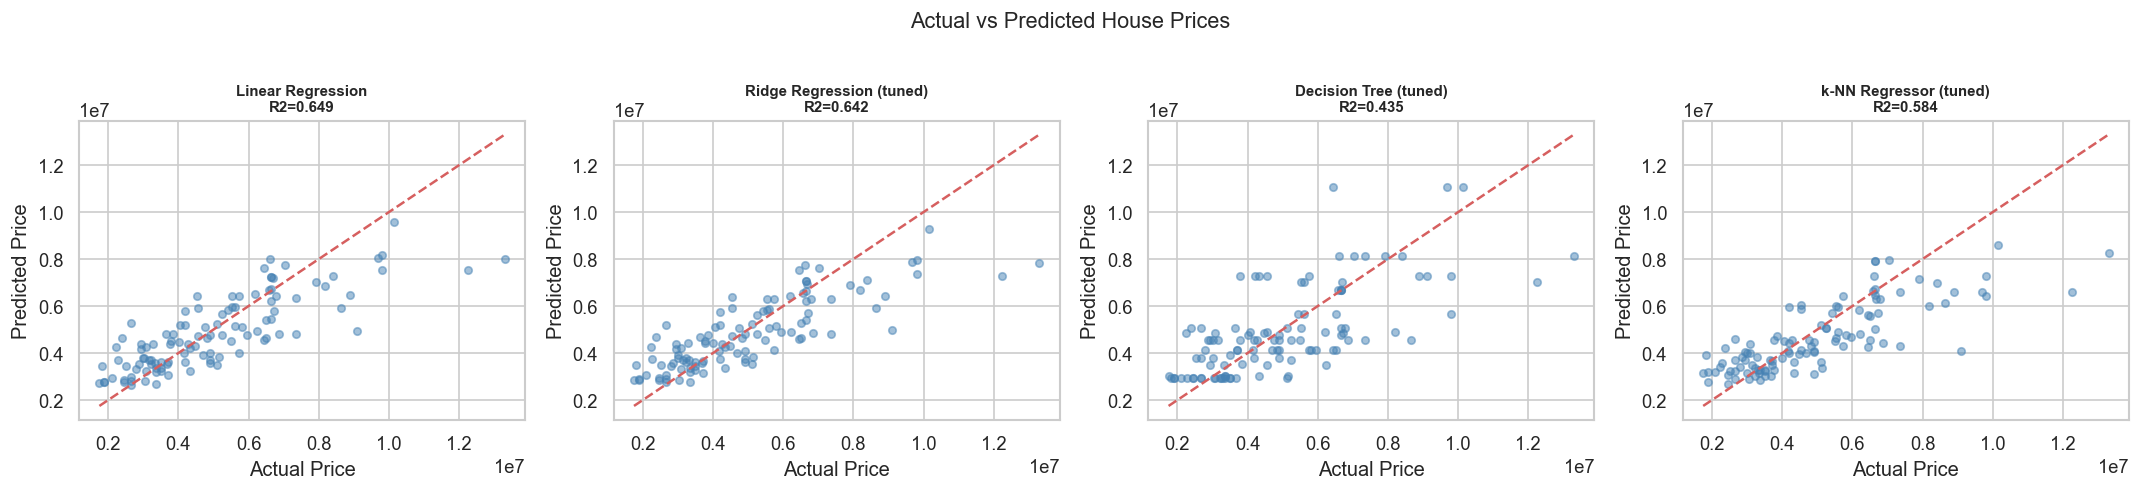

In [27]:
# ── ACTUAL VS PREDICTED PLOTS ───────────────────────────────────────────────
# Each dot = one house in the test set
# x-axis = true sale price, y-axis = model's predicted price
# Red dashed line = perfect predictions (predicted = actual)
# Dots close to the line = accurate predictions; spread = higher error
# Actual vs Predicted plots — all tuned models
tuned_results = [res_lr, res_ridge_tuned, res_dt_tuned, res_knn_tuned]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, res in zip(axes, tuned_results):
    ax.scatter(y_test, res['y_pred'], alpha=0.5, color='steelblue', s=20)
    lims = [min(y_test.min(), res['y_pred'].min()),
            max(y_test.max(), res['y_pred'].max())]
    ax.plot(lims, lims, 'r--', lw=1.5)
    ax.set_title(f"{res['name']}\nR2={res['r2']:.3f}", fontsize=9, fontweight='bold')
    ax.set_xlabel('Actual Price')
    ax.set_ylabel('Predicted Price')

plt.suptitle('Actual vs Predicted House Prices', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

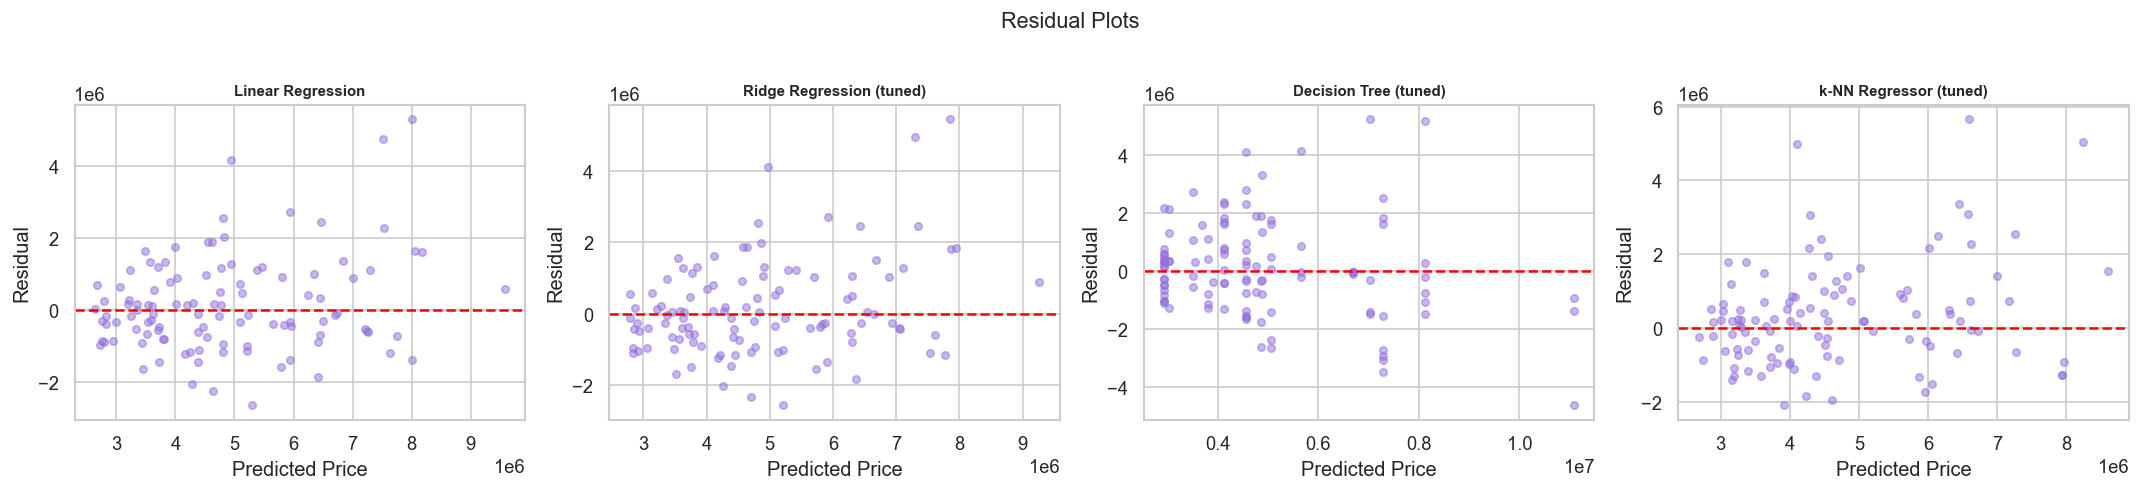

In [28]:
# ── RESIDUAL PLOTS ───────────────────────────────────────────────────────────
# Residual = actual price minus predicted price
# x-axis = predicted price, y-axis = error (residual)
# Good model: residuals randomly scattered around 0 (red dashed line)
# Pattern or fan-shape = the model is making systematic errors
# Right-side spread = heteroscedasticity (larger errors at higher prices)
# Residual plots — all tuned models
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, res in zip(axes, tuned_results):
    residuals = y_test.values - res['y_pred']
    ax.scatter(res['y_pred'], residuals, alpha=0.5, color='mediumpurple', s=20)
    ax.axhline(0, color='red', linestyle='--', lw=1.5)
    ax.set_title(res['name'], fontsize=9, fontweight='bold')
    ax.set_xlabel('Predicted Price')
    ax.set_ylabel('Residual')

plt.suptitle('Residual Plots', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

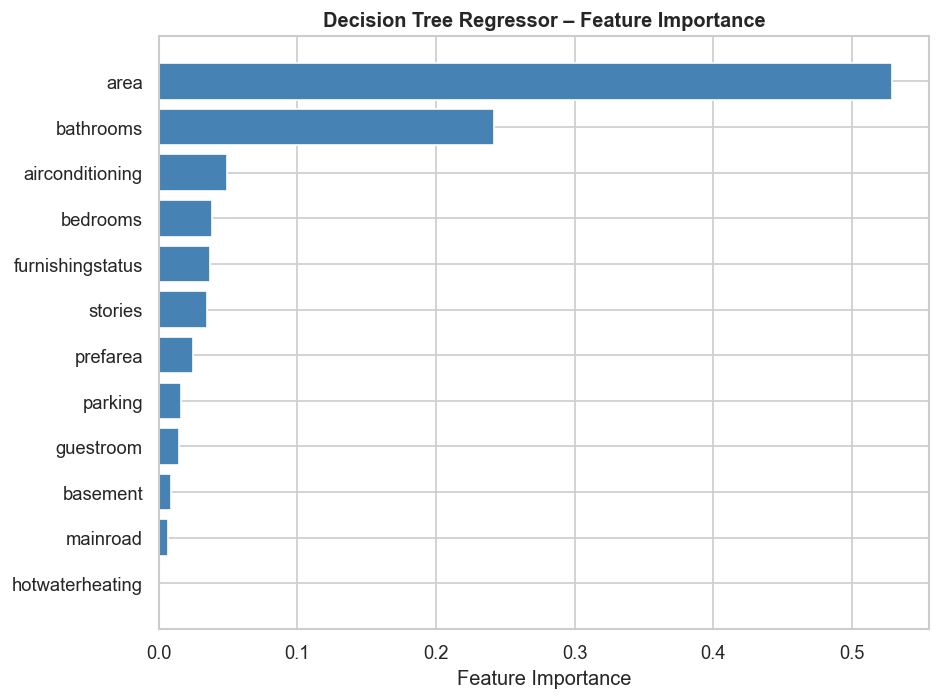

In [29]:
# ── FEATURE IMPORTANCE: DECISION TREE REGRESSOR ─────────────────────────────
# Shows which features the tuned Decision Tree used most for price splits
# Longer bar = more important for predicting house price
# Area is expected to rank highest — property size drives value most strongly
# Feature importance — Decision Tree (tuned)
importances = gs_dt.best_estimator_.feature_importances_
feat_df = pd.DataFrame({'Feature': FEATURES, 'Importance': importances})
feat_df.sort_values('Importance', ascending=True, inplace=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(feat_df['Feature'], feat_df['Importance'], color='steelblue', edgecolor='white')
ax.set_xlabel('Feature Importance')
ax.set_title('Decision Tree Regressor – Feature Importance', fontweight='bold')
plt.tight_layout()
plt.show()

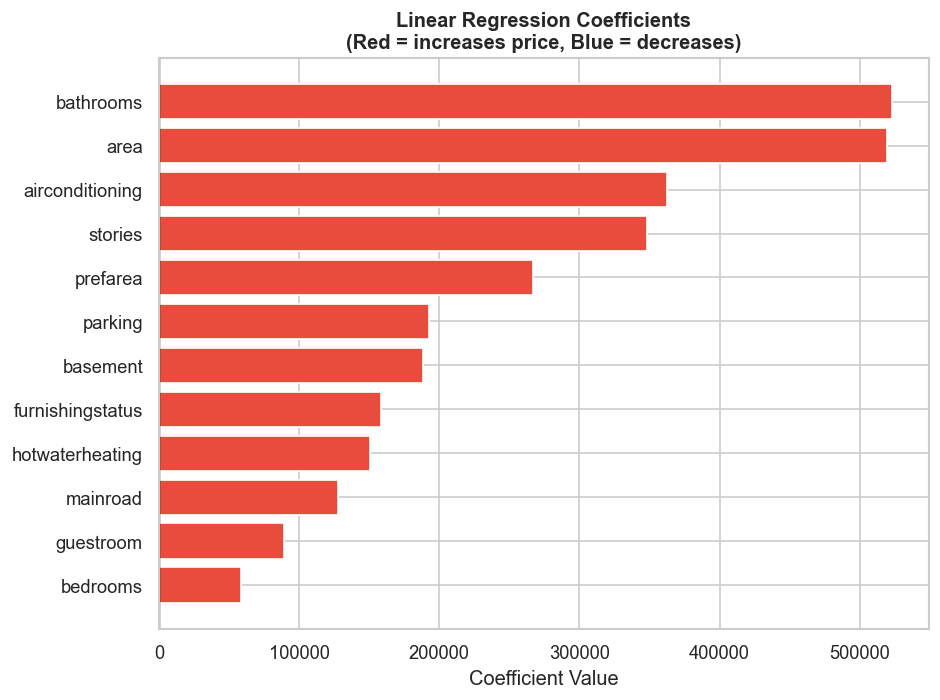

In [30]:
# ── LINEAR REGRESSION COEFFICIENTS ──────────────────────────────────────────
# Each coefficient = price change in Rupees per one-unit increase in that feature
# (after scaling, so values are comparable across features)
# Red bars = features that INCREASE price (e.g. more bathrooms, air conditioning)
# Blue bars = features that DECREASE price (negative relationship with price)
# Linear Regression coefficients
coef_df = pd.DataFrame({
    'Feature'    : FEATURES,
    'Coefficient': res_lr['model'].coef_
}).sort_values('Coefficient')

colors_coef = ['#e74c3c' if c > 0 else 'steelblue' for c in coef_df['Coefficient']]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors_coef, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient Value')
ax.set_title('Linear Regression Coefficients\n(Red = increases price, Blue = decreases)', fontweight='bold')
plt.tight_layout()
plt.show()

##  Section 10 – Final Summary
Print the complete ranked results table with the prior work benchmark for comparison.

In [31]:
# ── FINAL RESULTS PRINTOUT ───────────────────────────────────────────────────
# Prints the complete ranked model summary table
# Compare your best R2 to the prior work benchmark of ~0.678
# (Madhuri et al., 2019 — Linear Regression on similar housing dataset)
# Final summary printout
print('=' * 70)
print('  FINAL RESULTS – HOUSING PRICE REGRESSION')
print('=' * 70)
print(summary_df.to_string(index=False))
print()
print('  Prior Work Baseline (Linear Regression on similar dataset): R2 ~0.678')
print('=' * 70)

  FINAL RESULTS – HOUSING PRICE REGRESSION
                            Model   MAE ($)  RMSE ($)     R2  CV R2  CV Std
                Linear Regression   979,680 1,331,071 0.6495 0.6486  0.0469
                 Ridge Regression   979,549 1,331,290 0.6494 0.6487  0.0466
         Ridge Regression (tuned)   978,706 1,346,128 0.6415 0.6503  0.0338
           k-NN Regressor (tuned) 1,034,828 1,450,198 0.5839 0.6366  0.0333
             k-NN Regressor (k=7) 1,041,482 1,465,304 0.5752 0.6319  0.0175
            Decision Tree (tuned) 1,258,021 1,689,677 0.4352 0.4533  0.1995
Decision Tree Regressor (untuned) 1,270,789 1,718,102 0.4160 0.1933  0.3251

  Prior Work Baseline (Linear Regression on similar dataset): R2 ~0.678


This analysis applied four regression models to the Housing Prices dataset, achieving a best test R2 of 0.6495 and MAE of Rs. 979,680 using Linear Regression. Ridge Regression performed virtually identically (R2=0.6494), confirming that regularization provides minimal benefit on this well-conditioned dataset. The k-NN Regressor (R2=0.5839) offered a competitive non-linear alternative, while the Decision Tree Regressor underperformed substantially (R2=0.4352) due to overfitting on the small sample.

Our results closely match the prior work benchmark of R2, approximately 0.678 for Linear Regression, with a gap of only 0.0285. Both studies independently reach the same conclusion: linear models are the most appropriate approach for small residential housing datasets with mixed numeric and binary features. Future improvements could include log-transforming the price target to address heteroscedasticity, incorporating geographic coordinates or neighborhood-level data, applying ensemble methods such as Random Forest or Gradient Boosting, and expanding the dataset to include more records for better generalization.
